In [1]:
import os
import time
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from torchvision import transforms
from torchvision.models.segmentation import fcn_resnet50
from torchvision.models.segmentation import FCN_ResNet50_Weights

In [ ]:
# Carregar o modelo
weights = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

classes = weights.meta["categories"]

In [3]:
# Transformação
transform = weights.transforms()

In [4]:
# Listar as imagens

extensoes_validas = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

arquivos_imagem = [
    arquivo for arquivo in os.listdir("./data/") if arquivo.lower().endswith(extensoes_validas)
]

arquivos_imagem

['Laranja.jpg',
 'Peixes.jpg',
 'Familia.jpg',
 'Rua.jpg',
 'Horse.jpg',
 'Bus.jpg',
 'Ladrao3.jpg',
 'Ladrao2.jpg',
 'Colorido_Cinza.jpg',
 'Ladrao4.jpg',
 'Shopping.jpg',
 'Ladrao.jpg']

Tempo: 860.66 ms


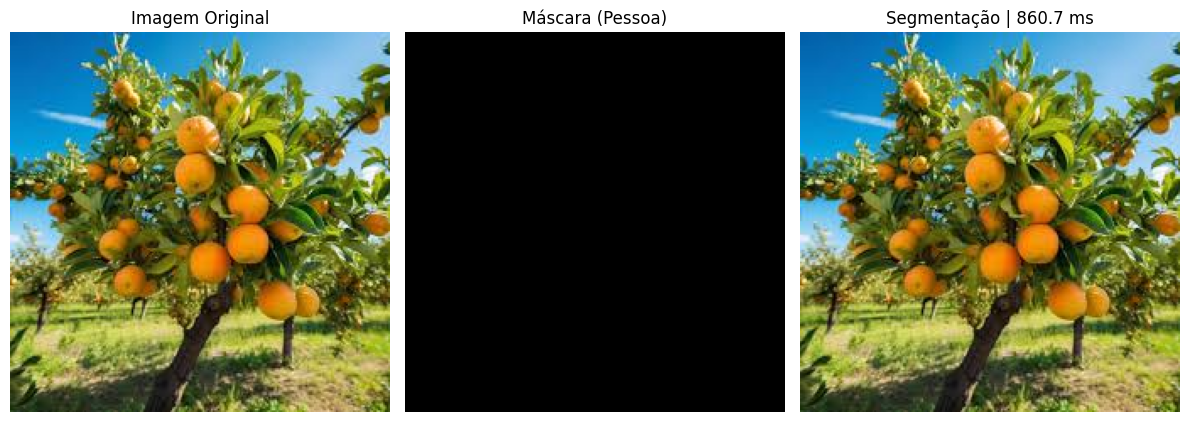

Tempo: 1058.23 ms


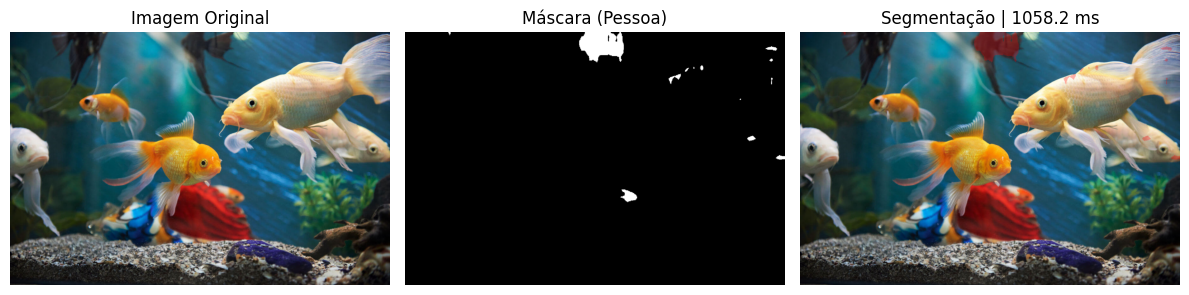

Tempo: 1273.04 ms


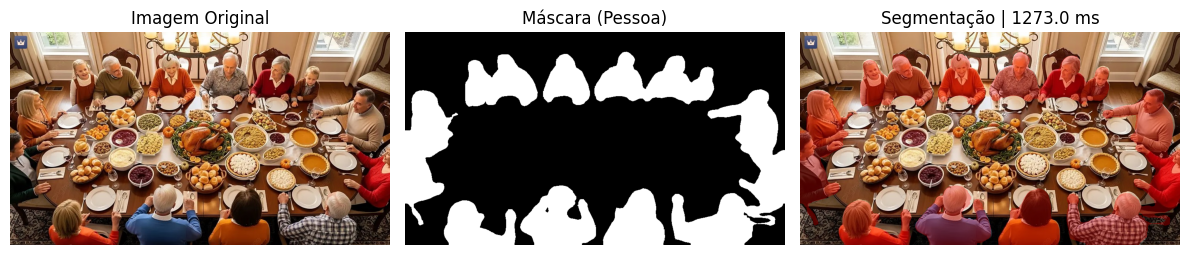

Tempo: 1263.12 ms


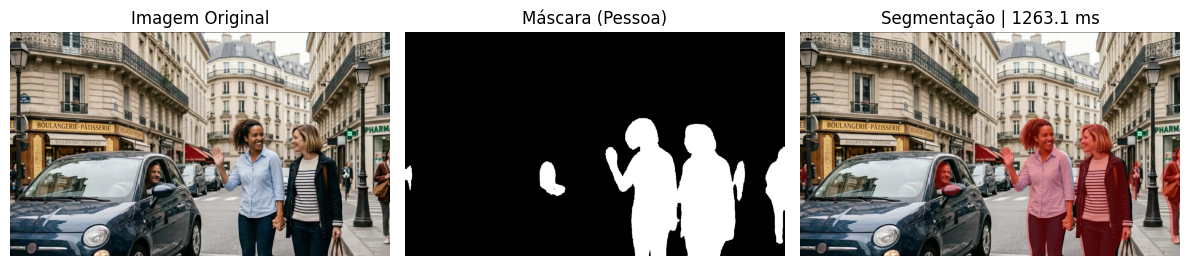

Tempo: 1009.18 ms


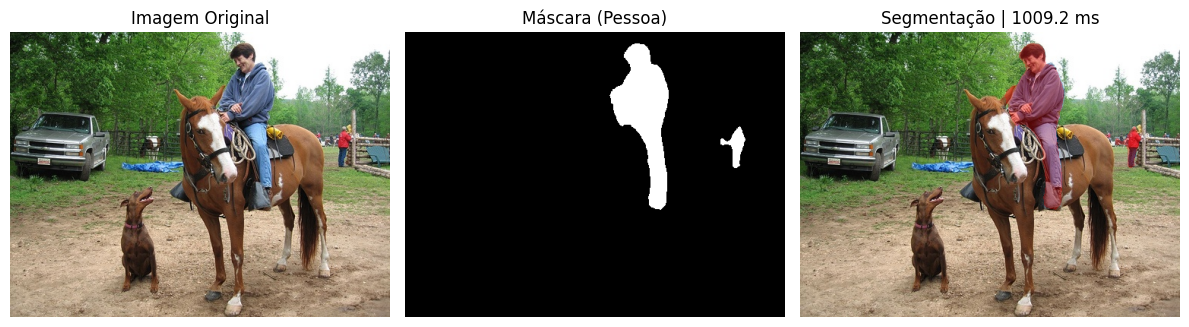

Tempo: 1053.87 ms


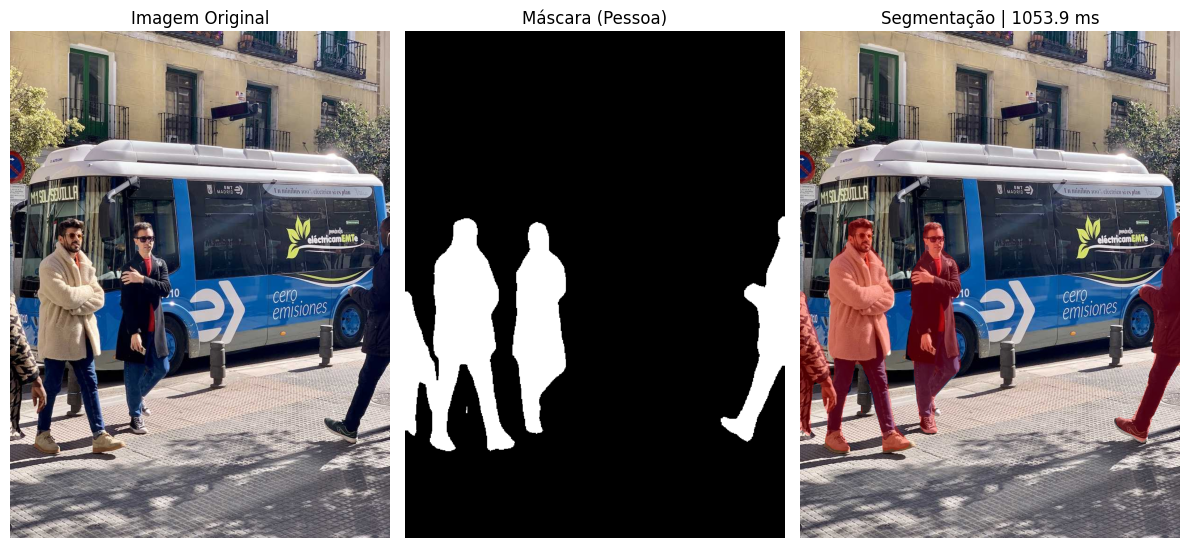

Tempo: 1494.21 ms


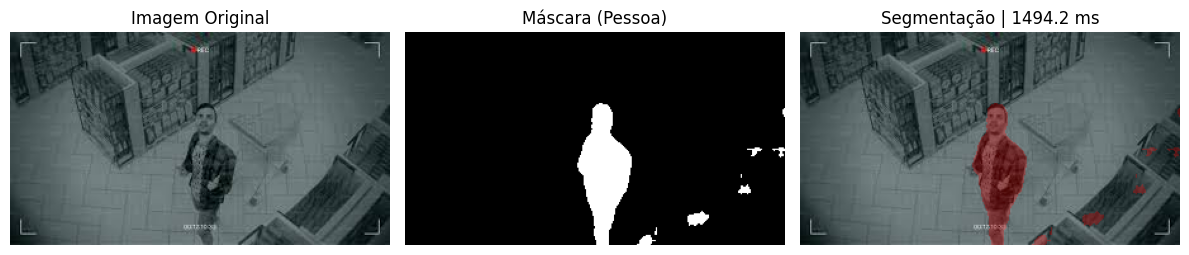

Tempo: 1155.25 ms


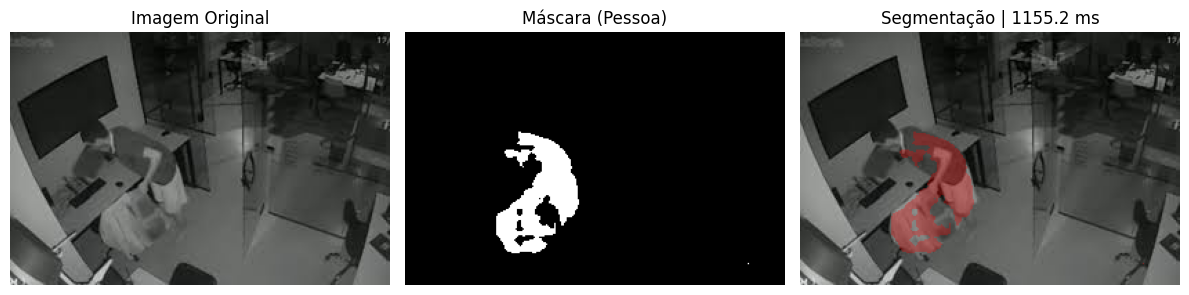

Tempo: 779.88 ms


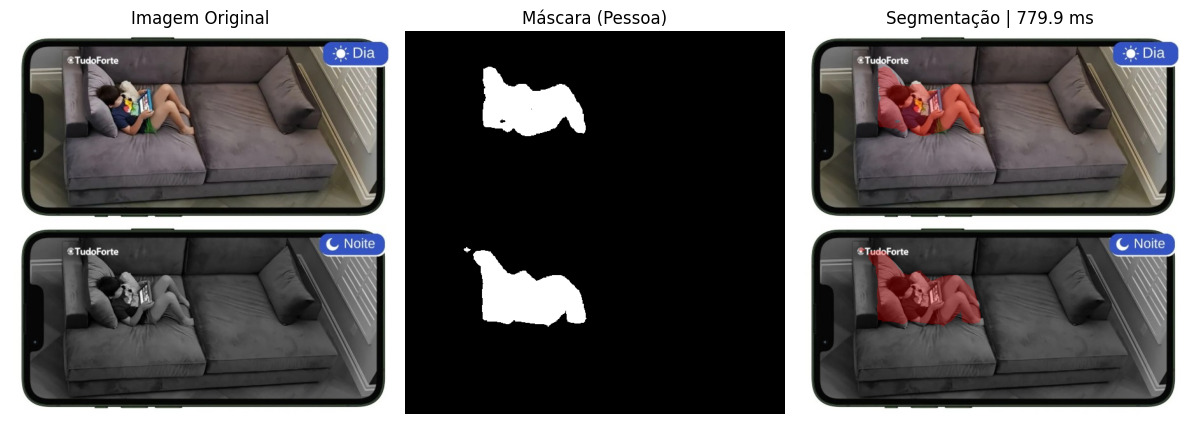

Tempo: 1169.66 ms


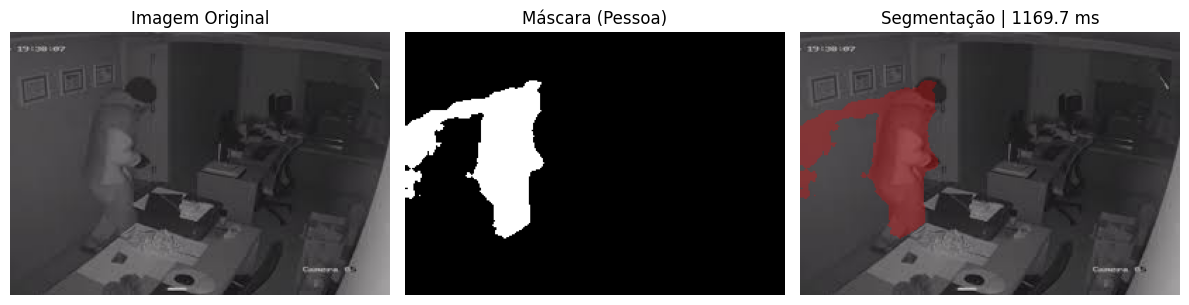

Tempo: 1429.23 ms


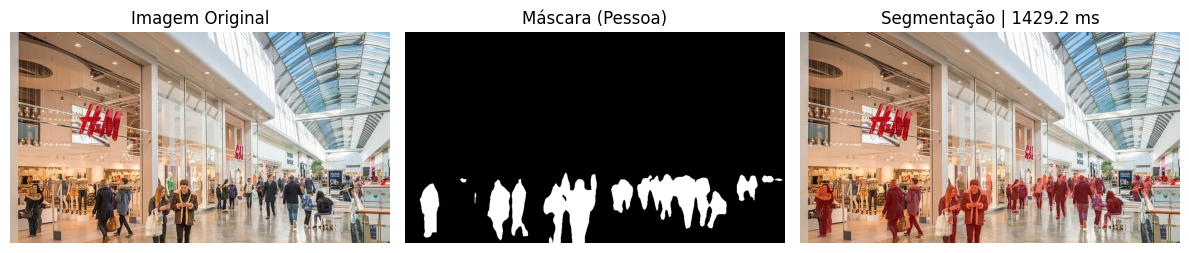

Tempo: 1482.03 ms


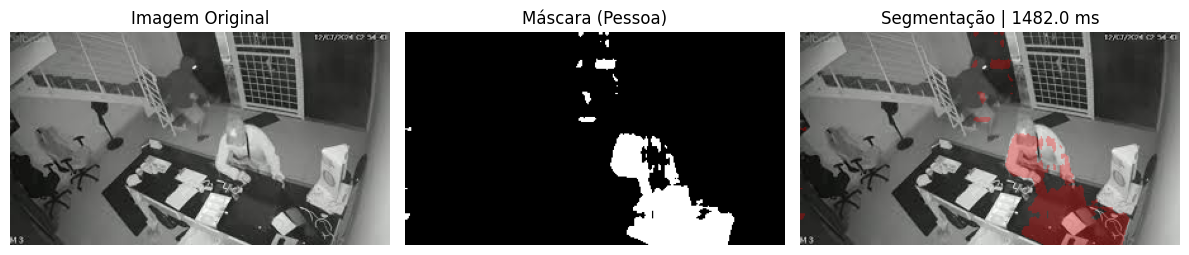

In [5]:
DIR = "./data/"

for img in arquivos_imagem:
    
    caminho = os.path.join(DIR, img)
    img_pil = Image.open(caminho).convert("RGB")
    img_original = np.array(img_pil)
    
    # Pré processamento
    input = transform(img_pil).unsqueeze(0) # Adicionar a dimensão do batch
    inicio = time.time()
    with torch.no_grad():
        output = model(input)["out"]
    fim = time.time()
    
    tempo_ms = (fim-inicio) * 1000
    
    print(f"Tempo: {tempo_ms:.2f} ms")

    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()
    mascara = (pred==15).astype(np.uint8)
    
    h, w = img_original.shape[:2]
    mascara = cv2.resize(mascara,(w,h), interpolation=cv2.INTER_NEAREST)
    
    # Sobreposição
    overlay = img_original.copy()
    overlay[mascara==1] = [255,0,0]
    
    resultado = cv2.addWeighted(img_original, 0.7, overlay,0.3,0)
    
    # Mostrar os resultados
    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(img_original)
    plt.title("Imagem Original")
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.imshow(mascara, cmap='gray')
    plt.title(f"Máscara (Pessoa)")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.imshow(resultado, cmap='gray')
    plt.title(f"Segmentação | {tempo_ms:.1f} ms")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    